1. Import


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import pandas as pd
import yaml
import sys
import numpy as np
from typing import Dict, Any, Tuple
import datetime
import platform
import warnings

module_path = str(Path.cwd().parent)
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"모듈 경로 추가 완료: '{module_path}'")

try:
    from src.data_loader import load_data
    from src.user_profiling import (
        compute_user_preference,
        compute_item_pops,
        compute_user_novelty,
        compute_user_shannon_entropy
    )
    print("✅ 사용자 정의 'src' 모듈 로드 완료")
except ImportError as e:
    print(f"🚨 오류: 'src' 모듈 로드 실패. {e}")
except Exception as e:
    print(f"🚨 오류: {e}")

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

system_name = platform.system()

if system_name == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system_name == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif system_name == 'Linux':
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    print("알 수 없는 OS")

plt.rcParams['axes.unicode_minus'] = False

print(f"✅ Matplotlib 한글 폰트 설정 완료 (Font: {plt.rcParams['font.family']})")

✅ 사용자 정의 'src' 모듈 로드 완료
✅ Matplotlib 한글 폰트 설정 완료 (Font: ['AppleGothic'])


2. Analysis Settings


In [7]:
# CONFIG_PATH = "../configs/book_crossing.yaml"
CONFIG_PATH = "../configs/movielens_1m.yaml"

config_path = Path(CONFIG_PATH)
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

SAVE_DIR = Path("../results") 
MODEL_NAMES = ["WMF", "EASEᴿ", "VAECF", "NeuMF"]
DATASET_NAME = config['dataset_name']
DIVERSIFICATION_MODES = ["None", "I_DIV", "A_DIV", "I_DIV+A_DIV"]
PERSONALIZE_MODES = ["P", "NP"]
METRIC_NAMES = ["NDCG@10", "Recall@10", "Precision@10", "MRR@10", "Novelty", "CatalogCoverage", "APLT", "ACLT"]
BASELINE_MODE = "None"
TODAY_DATE = pd.Timestamp.now().strftime("%Y%m%d")

print(f"데이터셋 분석 시작: {DATASET_NAME}")

데이터셋 분석 시작: movielens_1m


3. Helper Functions


In [8]:
def scale_distribution(
    data_series: pd.Series, 
    clip_min: float = 1e-9, 
    clip_max: float = 2.0 - 1e-9
) -> pd.Series:
    log1p_values = np.log1p(data_series)
    
    mean_log = np.mean(log1p_values)
    std_log = np.std(log1p_values) + 1e-9

    z_score = (log1p_values - mean_log) / std_log
    scaled_values = z_score * 0.5 + 1.0
    
    clipped_values = np.clip(scaled_values, clip_min, clip_max)
    
    return clipped_values

def prepare_user_profile_df(
    train_set: Any, 
    item_info: Dict[str, Any]
) -> Tuple[pd.DataFrame, Tuple[float, float]]:
    print("사용자 프로필 데이터 준비")
    
    item_pops = compute_item_pops(train_set)
    user_novelty = compute_user_novelty(train_set, item_pops)
    user_prefs = compute_user_preference(train_set, item_info)
    user_shannon = compute_user_shannon_entropy(user_prefs)

    df = pd.DataFrame.from_dict(user_novelty, orient='index', columns=['Novelty'])
    df['Shannon'] = df.index.map(user_shannon.get)
    df.dropna(inplace=True)
    print(f"원본 DataFrame 생성 완료. (사용자 수: {len(df)})")

    novelty_mean = df['Novelty'].mean()
    shannon_mean = df['Shannon'].mean()

    df['Novelty Group'] = np.where(df['Novelty'] >= novelty_mean, 'High Novelty', 'Low Novelty')
    df['Shannon Group'] = np.where(df['Shannon'] >= shannon_mean, 'High Shannon', 'Low Shannon')
    df['User Group'] = df['Shannon Group'] + '\n' + df['Novelty Group']

    df['scaled_novelty'] = scale_distribution(df['Novelty'])
    df['scaled_shannon'] = scale_distribution(df['Shannon'])
    
    print("데이터 스케일링 및 그룹핑 완료.")
    return df, (novelty_mean, shannon_mean)

def plot_quadrant_comparison(
    df: pd.DataFrame, 
    raw_means: Tuple[float, float], 
    output_path: Path
):
    print("플롯 생성 시작...")
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    novelty_mean, shannon_mean = raw_means

    group_order_full = [  
        'High Shannon\nHigh Novelty',
        'High Shannon\nLow Novelty',
        'Low Shannon\nHigh Novelty',
        'Low Shannon\nLow Novelty'
    ]
    colors = sns.color_palette("viridis", n_colors=len(group_order_full))
    color_map_full = dict(zip(group_order_full, colors))

    sns.scatterplot(
        data=df, x='Novelty', y='Shannon',
        hue='User Group', palette=color_map_full,
        alpha=0.6, s=50, ax=axes[0], legend=False
    )
    axes[0].axvline(novelty_mean, color='red', linestyle='--', linewidth=1.5, label=f'Novelty ({novelty_mean:.2f})')
    axes[0].axhline(shannon_mean, color='blue', linestyle='--', linewidth=1.5, label=f'Shannon ({shannon_mean:.2f})')
    axes[0].set_title('Before Scaling', fontsize=16)
    axes[0].set_xlabel(r'Novelty ($N(u)$)', fontsize=12)
    axes[0].set_ylabel(r'Shannon Entropy ($H(u)$)', fontsize=12)
    axes[0].legend(handles=axes[0].lines, loc='upper right', title="Raw Means")
    
    sns.scatterplot(
        data=df, x='scaled_novelty', y='scaled_shannon',
        hue='User Group', palette=color_map_full,
        alpha=0.6, s=50, ax=axes[1], legend=False
    )
    axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Novelty (1.0)')
    axes[1].axhline(1.0, color='blue', linestyle='--', linewidth=1.5, label='Shannon (1.0)')
    axes[1].set_title(r'After Scaling & Winsorization', fontsize=16)
    axes[1].set_xlabel(r'Scaled Novelty ($\tilde{N}(u)$)', fontsize=12)
    axes[1].set_ylabel(r'Scaled Shannon Entropy ($\tilde{H}(u)$)', fontsize=12)
    axes[1].legend(handles=axes[1].lines, loc='upper right', title="Scaled Means")

    patch_handles = [mpatches.Patch(color=color_map_full[group_label],
                                      label=group_label.replace('\n', ', '))
                     for group_label in group_order_full]

    if patch_handles:
        fig.legend(handles=patch_handles, loc='lower center', 
                   bbox_to_anchor=(0.5, 0), 
                   ncol=4, 
                   title='User Group', fontsize=12)
    
    try:
        plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    except ValueError:
        print("경고: tight_layout 실패")

    fig.savefig(output_path)
    print(f"✅ 플롯 저장 완료: {output_path}")
    plt.show()
    plt.close(fig)

def plot_user_preference_comparison(
    uidx: int,
    user_profile_mle: Dict[int, Dict[str, float]],
    user_profile_map: Dict[int, Dict[str, float]],
    output_path: Path
):
    print(f"사용자 {uidx}의 선호도 분포 시각화")
    
    mle_data = user_profile_mle.get(uidx, {})
    map_data = user_profile_map.get(uidx, {})

    if not mle_data:
        print(f"경고: 사용자 {uidx}의 데이터가 없음")
        return

    categories = sorted(set(mle_data.keys()) | set(map_data.keys()))
    
    if not categories:
        print("표시할 카테고리가 없음")
        return

    mle_vals = [mle_data.get(g, 0.0) for g in categories]
    map_vals = [map_data.get(g, 0.0) for g in categories]
    
    x = np.arange(len(categories))
    width = 0.35 

    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.bar(x - width/2, mle_vals, width, label='User Preference (MLE)', alpha=0.8, color='skyblue')
    ax.bar(x + width/2, map_vals, width, label='User Preference (Laplace)', alpha=0.8, color='orange')

    max_val = max(max(mle_vals, default=0), max(map_vals, default=0))
    if max_val == 0:
        y_top = 1.0 
    else:
        y_top = max_val * 1.1 
    
    ax.set_ylim(0, y_top)

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.set_xlabel("Categories", fontsize=12)

    ax.set_ylabel("Preference Probability P(g|u)", fontsize=12)
    ax.set_title(f"User {uidx} - Preference Distribution Comparison (MLE vs Laplace)", fontsize=16) # 제목 수정
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    
    fig.savefig(output_path)
    print(f"✅ 사용자 {uidx} 플롯 저장 완료: {output_path}")
    plt.show()
    plt.close(fig)

4. Analysis - User Profile Distribution


데이터 로드 완료
사용자 프로필 데이터 준비
원본 DataFrame 생성 완료. (사용자 수: 6040)
데이터 스케일링 및 그룹핑 완료.
플롯 생성 시작...
✅ 플롯 저장 완료: ../results/20251118_movielens_1m_quadrant_comparison_shannon.png


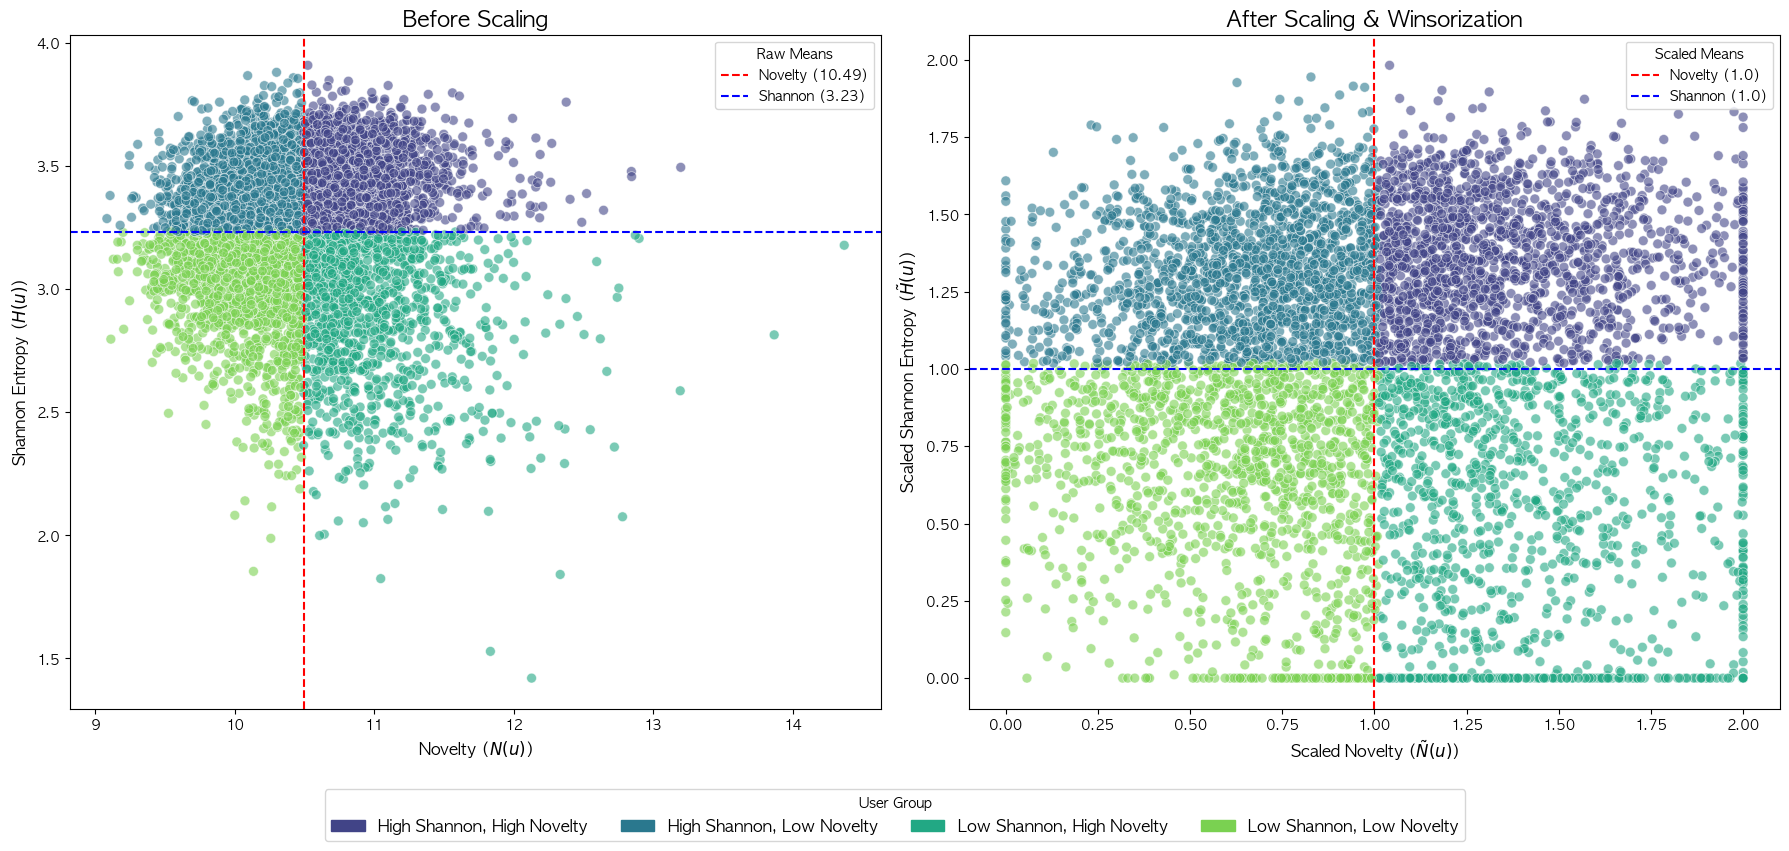

--- movielens_1m 데이터셋 분석 완료 ---


In [9]:
try:
    corrected_data_path = Path(f"../{config['data_path']}")
    raw_df, eval_method, item_info = load_data(
        dataset_name=config['dataset_name'],
        path=corrected_data_path,
        split_config=config['data_split'],
        seed=config['seed'],
        verbose=False
    )
    train_set = eval_method.train_set
    print("데이터 로드 완료")

    df, raw_means = prepare_user_profile_df(train_set, item_info)
    
    today_date = datetime.date.today().strftime("%Y%m%d")
    output_path = SAVE_DIR / f"{today_date}_{DATASET_NAME}_quadrant_comparison_shannon.png"
    
    plot_quadrant_comparison(df, raw_means, output_path)
    
    print(f"--- {DATASET_NAME} 데이터셋 분석 완료 ---")

except FileNotFoundError:
    print(f"🚨 오류: {CONFIG_PATH} 또는 데이터 경로를 찾을 수 없음")
except Exception as e:
    print(f"🚨 분석 실행 중 오류 발생: {e}")

4. Analysis - User Preference Comparison


✅ 데이터 로드 완료
사용자 666의 선호도 분포 시각화
✅ 사용자 666 플롯 저장 완료: ../results/20251118_movielens_1m_user_666_pref_dist_MLE_LAPLACE.png


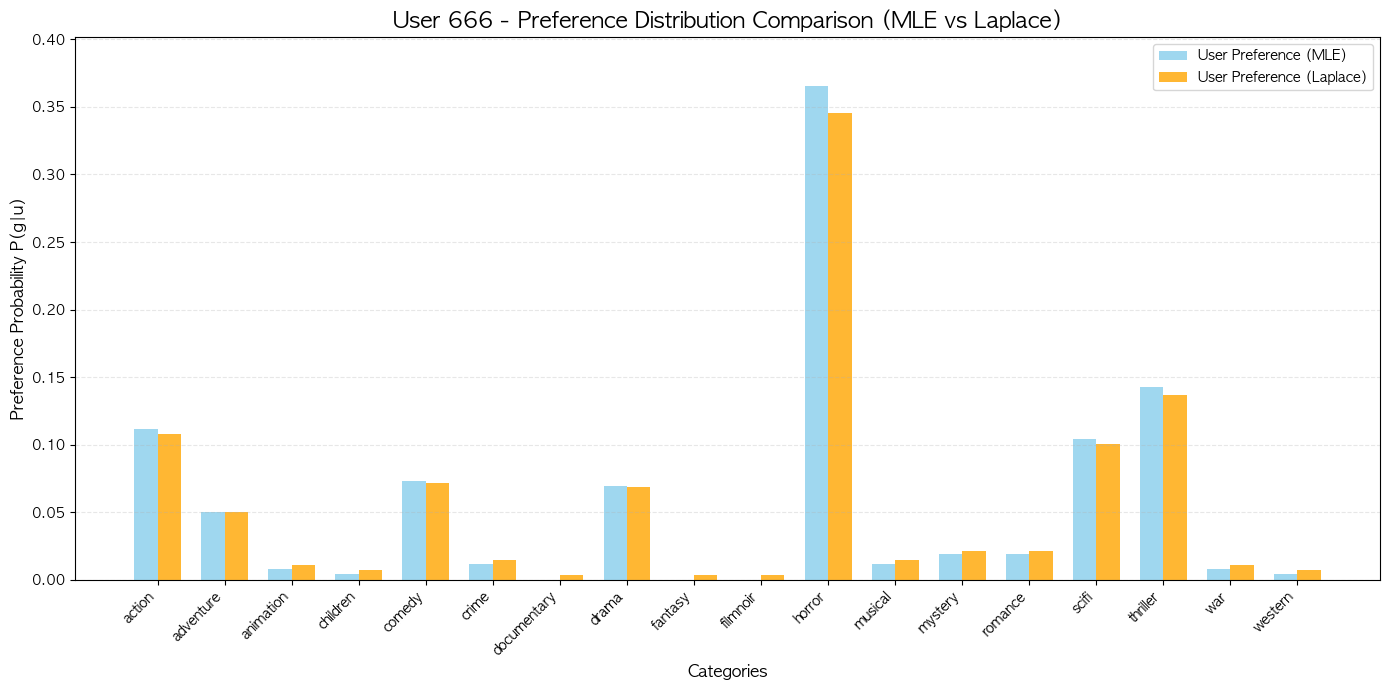


--- 분석 및 시각화 완료 ---
저장된 경로: ../results/20251118_movielens_1m_user_666_pref_dist_MLE_LAPLACE.png


In [10]:
try:
    corrected_data_path = Path(f"../{config['data_path']}")

    _, eval_method, item_info = load_data(
        dataset_name=config['dataset_name'],
        path=corrected_data_path,
        split_config=config['data_split'],
        seed=config['seed'],
        verbose=False
    )
    
    train_set = eval_method.train_set
    print("✅ 데이터 로드 완료")

    today_date = datetime.date.today().strftime("%Y%m%d")

    user_profile_mle = compute_user_preference(
        train_set, item_info, method="MLE"
    )
    
    user_profile_map = compute_user_preference(
        train_set, item_info, method="MAP", alpha_value=1.0
    )

    UID_TO_PLOT = 666 
    output_path = SAVE_DIR / f"{today_date}_{DATASET_NAME}_user_{UID_TO_PLOT}_pref_dist_MLE_LAPLACE.png"
    
    plot_user_preference_comparison(
        uidx=UID_TO_PLOT,
        user_profile_mle=user_profile_mle,
        user_profile_map=user_profile_map,
        output_path=output_path
    )
    
    print(f"\n--- 분석 및 시각화 완료 ---")
    print(f"저장된 경로: {output_path}")

except FileNotFoundError:
    print(f"🚨 오류: 설정 파일({CONFIG_PATH})을 찾을 수 없음")
except KeyError as e:
    print(f"🚨 오류: 설정 파일에 필요한 키 없 {e}")
except Exception as e:
    print(f"🚨 실행 중 오류 발생: {e}")
    import traceback
    traceback.print_exc()